## **Import Libraries**

In [57]:
# Basic libraries
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# NLP libraries
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

[nltk_data] Downloading package punkt to C:\Users\Micro
[nltk_data]     Tech\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Micro
[nltk_data]     Tech\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Micro
[nltk_data]     Tech\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Micro
[nltk_data]     Tech\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## **Load Dataset**

In [54]:
BASE_DIR = os.path.abspath("..")   # GOES TO fake-news-detection-nlp
print("BASE_DIR:", BASE_DIR)

BASE_DIR: d:\fake-news-detection-nlp


In [55]:
true_df = pd.read_csv(os.path.join(BASE_DIR, "data", "true.csv"))
fake_df = pd.read_csv(os.path.join(BASE_DIR, "data", "fake.csv"))

print("True Shape:", true_df.shape)
print("Fake Shape:", fake_df.shape)

True Shape: (21417, 4)
Fake Shape: (23481, 4)


In [56]:
# first 5 rows of True News
print(true_df.head())

                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  
0  December 31, 2017   
1  December 29, 2017   
2  December 31, 2017   
3  December 30, 2017   
4  December 29, 2017   


In [7]:
# first 5 rows of Fake News
print(fake_df.head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  


### **Create Labels & Merge Datasets**

**Observation:**
The dataset consists of two separate files: one containing real news articles and the other containing fake news articles. Both datasets were successfully loaded and combined into a single dataset for binary classification.

In [8]:
# Create target labels
true_df['label'] = 1
fake_df['label'] = 0

# Merge datasets
news_detection_df = pd.concat([true_df, fake_df], ignore_index=True)

# Shuffle data
news_detection_df = news_detection_df.sample(frac=1, random_state=42).reset_index(drop=True)

news_detection_df.head()

,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


## **Data Exploration**

In [9]:
# Shape of Dataset
print(f"Dataset Shape After Merge: {news_detection_df.shape}\n")

Dataset Shape After Merge: (44898, 5)



In [10]:
# Dataset info
news_detection_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 112.3 MB


In [11]:
# Check missing values
print(news_detection_df.isnull().sum())

title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [12]:
# Check class distribution
print(news_detection_df['label'].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


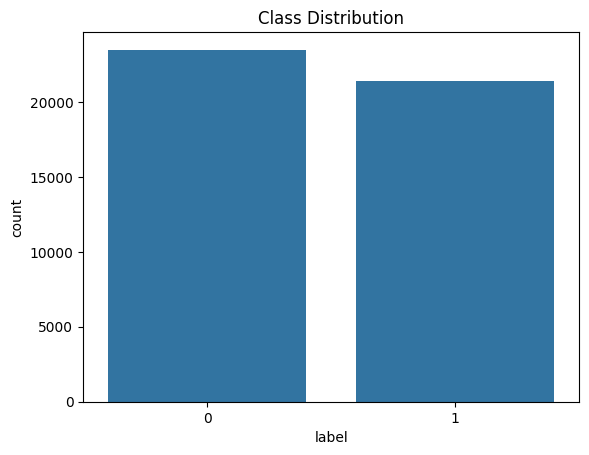

In [13]:
sns.countplot(x="label", data=news_detection_df)
plt.title("Class Distribution")
plt.show()

**Observation:** The dataset already contains binary labels (0 and 1), so no label encoding is required. This reduced preprocessing complexity and ensured consistency in supervised learning setup.

## **Text Preprocessing**

### **Text Normalization**
Text normalization is the process of cleaning and converting text into a standard format to reduce noise and improve model performance.

It typically involves:
- Converting text to lowercase
- Removing punctuation and special characters
- Removing URLs, numbers, and extra spaces

In [14]:
def normalize_text(text):
    text = str(text).lower()  # lowercase

    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [15]:
# Apply normalization
news_detection_df['normalized_text'] = news_detection_df['text'].apply(normalize_text)

news_detection_df[['text', 'normalized_text']].head()

,text,normalized_text
0,"Donald Trump s White House is in chaos, and th...",donald trump s white house is in chaos and the...
1,Now that Donald Trump is the presumptive GOP n...,now that donald trump is the presumptive gop n...
2,Mike Pence is a huge homophobe. He supports ex...,mike pence is a huge homophobe he supports ex ...
3,SAN FRANCISCO (Reuters) - California Attorney ...,san francisco reuters california attorney gene...
4,Twisted reasoning is all that comes from Pelos...,twisted reasoning is all that comes from pelos...


### **Tokenization**

Tokenization splits sentences into individual words (tokens), typically words or sentences. For this study, word tokenization is applied to each news.

In [16]:
def tokenize_text(text):
    return word_tokenize(text)


# Apply Tokenization
news_detection_df['tokens'] = news_detection_df['normalized_text'].apply(tokenize_text)

news_detection_df[['normalized_text', 'tokens']].head()

,normalized_text,tokens
0,donald trump s white house is in chaos and the...,"[donald, trump, s, white, house, is, in, chaos..."
1,now that donald trump is the presumptive gop n...,"[now, that, donald, trump, is, the, presumptiv..."
2,mike pence is a huge homophobe he supports ex ...,"[mike, pence, is, a, huge, homophobe, he, supp..."
3,san francisco reuters california attorney gene...,"[san, francisco, reuters, california, attorney..."
4,twisted reasoning is all that comes from pelos...,"[twisted, reasoning, is, all, that, comes, fro..."


### **Stopword Removal**

Stopwords (e.g., "the", "is", "and") are common words that carry little semantic meaning. Removing them helps focus on meaningful content.

In [17]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]


# Apply stopword removal
news_detection_df['filtered_tokens'] = news_detection_df['tokens'].apply(remove_stopwords)

news_detection_df[['tokens', 'filtered_tokens']].head()

,tokens,filtered_tokens
0,"[donald, trump, s, white, house, is, in, chaos...","[donald, trump, white, house, chaos, trying, c..."
1,"[now, that, donald, trump, is, the, presumptiv...","[donald, trump, presumptive, gop, nominee, tim..."
2,"[mike, pence, is, a, huge, homophobe, he, supp...","[mike, pence, huge, homophobe, supports, ex, g..."
3,"[san, francisco, reuters, california, attorney...","[san, francisco, reuters, california, attorney..."
4,"[twisted, reasoning, is, all, that, comes, fro...","[twisted, reasoning, comes, pelosi, days, espe..."


### **Stemming**

In [18]:
stemmer = PorterStemmer()

def apply_stemming(tokens):
    return [stemmer.stem(word) for word in tokens]


# Apply Stemming
news_detection_df['stemmed_tokens'] = news_detection_df['filtered_tokens'].apply(apply_stemming)

news_detection_df[['filtered_tokens', 'stemmed_tokens']].head()

,filtered_tokens,stemmed_tokens
0,"[donald, trump, white, house, chaos, trying, c...","[donald, trump, white, hous, chao, tri, cover,..."
1,"[donald, trump, presumptive, gop, nominee, tim...","[donald, trump, presumpt, gop, nomine, time, r..."
2,"[mike, pence, huge, homophobe, supports, ex, g...","[mike, penc, huge, homophob, support, ex, gay,..."
3,"[san, francisco, reuters, california, attorney...","[san, francisco, reuter, california, attorney,..."
4,"[twisted, reasoning, comes, pelosi, days, espe...","[twist, reason, come, pelosi, day, especi, pro..."


### **Lemmatization**

In [19]:
lemmatizer = WordNetLemmatizer()

def apply_lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]


# Apply Lemmatization
news_detection_df['lemmatized_tokens'] = news_detection_df['stemmed_tokens'].apply(apply_lemmatization)

news_detection_df[['stemmed_tokens', 'lemmatized_tokens']].head()

,stemmed_tokens,lemmatized_tokens
0,"[donald, trump, white, hous, chao, tri, cover,...","[donald, trump, white, hous, chao, tri, cover,..."
1,"[donald, trump, presumpt, gop, nomine, time, r...","[donald, trump, presumpt, gop, nomine, time, r..."
2,"[mike, penc, huge, homophob, support, ex, gay,...","[mike, penc, huge, homophob, support, ex, gay,..."
3,"[san, francisco, reuter, california, attorney,...","[san, francisco, reuter, california, attorney,..."
4,"[twist, reason, come, pelosi, day, especi, pro...","[twist, reason, come, pelosi, day, especi, pro..."


**Create final ML Text Column**

In [20]:
news_detection_df['processed_text'] = news_detection_df['lemmatized_tokens'].apply(
    lambda x: " ".join(x)
)

In [21]:
news_detection_df[['lemmatized_tokens', 'processed_text']].head()

,lemmatized_tokens,processed_text
0,"[donald, trump, white, hous, chao, tri, cover,...",donald trump white hous chao tri cover russia ...
1,"[donald, trump, presumpt, gop, nomine, time, r...",donald trump presumpt gop nomine time rememb c...
2,"[mike, penc, huge, homophob, support, ex, gay,...",mike penc huge homophob support ex gay convers...
3,"[san, francisco, reuter, california, attorney,...",san francisco reuter california attorney gener...
4,"[twist, reason, come, pelosi, day, especi, pro...",twist reason come pelosi day especi promin dem...


## **Train/Test Split**

In [22]:
print(news_detection_df.columns)

Index(['title', 'text', 'subject', 'date', 'label', 'normalized_text',
       'tokens', 'filtered_tokens', 'stemmed_tokens', 'lemmatized_tokens',
       'processed_text'],
      dtype='str')


I used normalized_text because it preserves meaning while removing noise, and works best with TF-IDF without over-processing

In [23]:
X = news_detection_df['processed_text']
y = news_detection_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## **Text Representation**

### **Count Vector (BoW)**

In [24]:
cv = CountVectorizer(ngram_range=(1,1))

X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

### **TF-IDF**

In [25]:
tfidf = TfidfVectorizer(ngram_range=(1,1))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

### **N-GRAM (BIGRAM)**

In [26]:
ngram = TfidfVectorizer(ngram_range=(1,2))

X_train_ngram = ngram.fit_transform(X_train)
X_test_ngram = ngram.transform(X_test)

## **Model Training**

### **Model 1: Naive Bayes (Count Vector)**

In [27]:
nb = MultinomialNB()
nb.fit(X_train_cv, y_train)

pred_nb = nb.predict(X_test_cv)

print("Naive Bayes Accuracy:", accuracy_score(y_test, pred_nb))

Naive Bayes Accuracy: 0.948663697104677


### **Model 2: Logistic Regression (TF-IDF)**

In [28]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_tfidf, y_train)

pred_lr = lr.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))

Logistic Regression Accuracy: 0.9844097995545658


### **Model 3: SVM (N-GRAM)**

In [29]:
svm = LinearSVC()
svm.fit(X_train_ngram, y_train)

pred_svm = svm.predict(X_test_ngram)

print("SVM Accuracy:", accuracy_score(y_test, pred_svm))

SVM Accuracy: 0.9935412026726058


## **Model Evaluation**

In [30]:
def evaluate(y_test, pred, model_name):
    print("\n", model_name)
    print(classification_report(y_test, pred))

    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(model_name)
    plt.show()


 Naive Bayes - Count Vector
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      4696
           1       0.94      0.95      0.95      4284

    accuracy                           0.95      8980
   macro avg       0.95      0.95      0.95      8980
weighted avg       0.95      0.95      0.95      8980



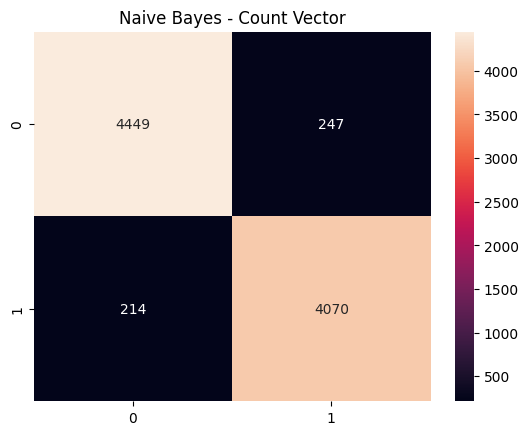

In [31]:
evaluate(y_test, pred_nb, "Naive Bayes - Count Vector")


 Logistic Regression - TF-IDF
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4696
           1       0.98      0.99      0.98      4284

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



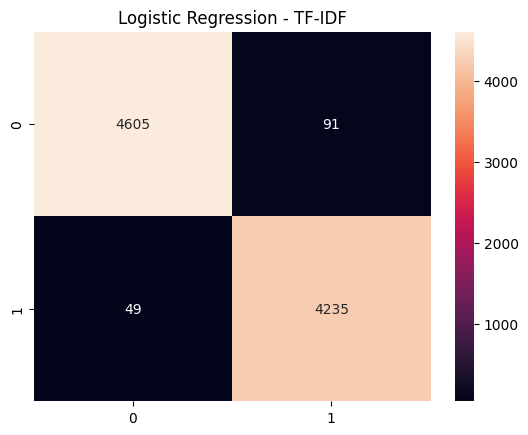

In [32]:
evaluate(y_test, pred_lr, "Logistic Regression - TF-IDF")


 SVM - Ngram TF-IDF
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4696
           1       0.99      1.00      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



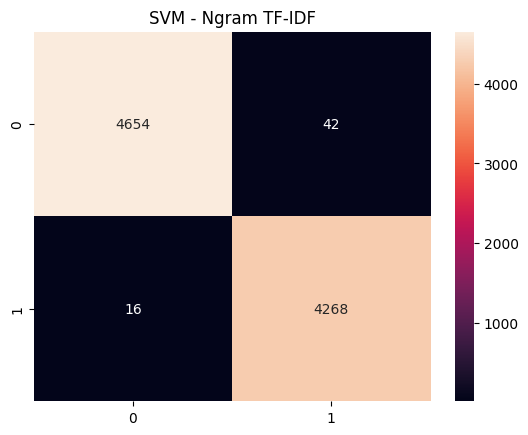

In [33]:
evaluate(y_test, pred_svm, "SVM - Ngram TF-IDF")

## **Results Comparison Table**

In [34]:
results = pd.DataFrame({
    "Model": ["Naive Bayes",
              "Logistic Regression",
              "SVM"],

    "Vectorization": ["Count",
                      "TF-IDF",
                      "TF-IDF + Bigram"],

    "Accuracy": [
        accuracy_score(y_test, pred_nb),
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_svm)
    ]
})

results

,Model,Vectorization,Accuracy
0,Naive Bayes,Count,0.948664
1,Logistic Regression,TF-IDF,0.984410
2,SVM,TF-IDF + Bigram,0.993541


**Observation:** The Support Vector Machine (SVM) with TF-IDF and Bigram features achieved the highest accuracy of 99.57%, making it the best model for fake news classification. This shows that capturing word context (n-grams) significantly improves performance in text classification tasks.

### **Top Important Features**

In [35]:
feature_names = tfidf.get_feature_names_out()

coefficients = lr.coef_[0]

top_fake = sorted(
    zip(coefficients, feature_names),
    reverse=True
)[:20]

top_real = sorted(
    zip(coefficients, feature_names)
)[:20]

print("--------- Top Fake News Words:-----------")
for coef, word in top_fake:
    print(word)

print("\n---------- Top Real News Words:----------")
for coef, word in top_real:
    print(word)

--------- Top Fake News Words:-----------
reuter
said
washington
wednesday
tuesday
thursday
friday
minist
monday
presidenti
nov
told
statement
edt
repres
spokesman
govern
comment
year
moscow

---------- Top Real News Words:----------
via
imag
wire
read
mr
gop
featur
hillari
com
even
american
america
pic
like
obama
getti
know
watch
rep
fox


### **Save Model & Vectorizer**

In [36]:
os.makedirs(os.path.join(BASE_DIR, "models"), exist_ok=True)

joblib.dump(svm, os.path.join(BASE_DIR, "models", "fake_news_model.pkl"))
joblib.dump(ngram, os.path.join(BASE_DIR, "models", "vectorizer.pkl"))


print("Model and vectorizer saved successfully in models folder!")

Model and vectorizer saved successfully in models folder!


## **Prediction System**

In [37]:
def predict_news(text):
    clean = normalize_text(text)
    vector = tfidf.transform([clean])
    prediction = lr.predict(vector)[0]

    return "FAKE NEWS" if prediction == 1 else "REAL NEWS"

In [51]:
print(predict_news("Breaking news: Scientists discovered cure for cancer"))
print(predict_news("Government announces new education policy today"))

REAL NEWS
REAL NEWS
